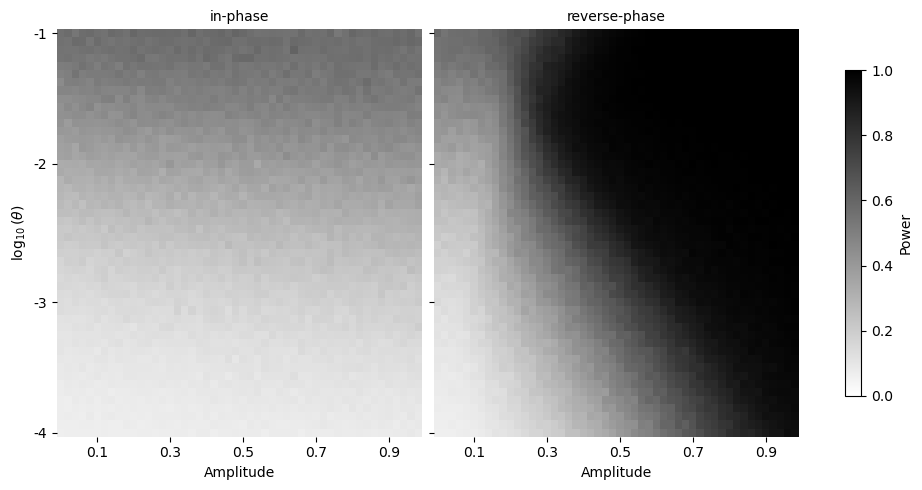

In [1]:
# Cell 0: Power Heatmap (sync vs async)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

df = pd.read_csv("outputs/crlb.csv", index_col=None)
df = df.rename(columns={'delta': 'amplitude'})
df['phase2'] = df.phase2.replace({np.pi: 'reverse-phase', 0: 'in-phase'})
df['crlb'] = df.crlb / np.sqrt(20)
df['log_crlb'] = np.log10(df.crlb)
df['log_theta'] = np.log10(df.theta)

z_alpha = 1.645
df['power'] = 1 - norm.cdf(z_alpha - df['theta'] / df['crlb'])
df_agg = df.groupby(['theta', 'amplitude', 'phase2'])['power'].mean().reset_index()

def draw_heatmap(data, **kwargs):
    pivot = data.pivot(index='theta', columns='amplitude', values='power')
    thetas = pivot.index.values
    amplitudes = pivot.columns.values
    ax = plt.gca()
    sns.heatmap(pivot, ax=ax, cmap='gray_r', vmin=0, vmax=1, cbar=False,
                xticklabels=False, yticklabels=False)
    ax.invert_yaxis()
    x_desired = [0.1, 0.3, 0.5, 0.7, 0.9]
    x_positions = [np.argmin(np.abs(amplitudes - x)) + 0.5 for x in x_desired]
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_desired)
    y_desired_theta = [0.1, 0.01, 0.001, 0.0001]
    y_positions = [np.argmin(np.abs(thetas - y)) + 0.5 for y in y_desired_theta]
    ax.set_yticks(y_positions)
    ax.set_yticklabels(['-1', '-2', '-3', '-4'])

g = sns.FacetGrid(df_agg, col='phase2', height=5, aspect=1)
g.map_dataframe(draw_heatmap)
g.set_axis_labels('Amplitude', r'$\log_{10}(\theta)$')
g.set_titles(col_template='{col_name}')
sm = plt.cm.ScalarMappable(cmap='gray_r', norm=plt.Normalize(0, 1))
sm.set_array([])
g.figure.colorbar(sm, ax=g.axes, location='right', shrink=0.8, label='Power')
plt.savefig("pix/power.png", dpi=150, bbox_inches='tight')
plt.savefig("pix/power.pdf", bbox_inches='tight')
plt.show()

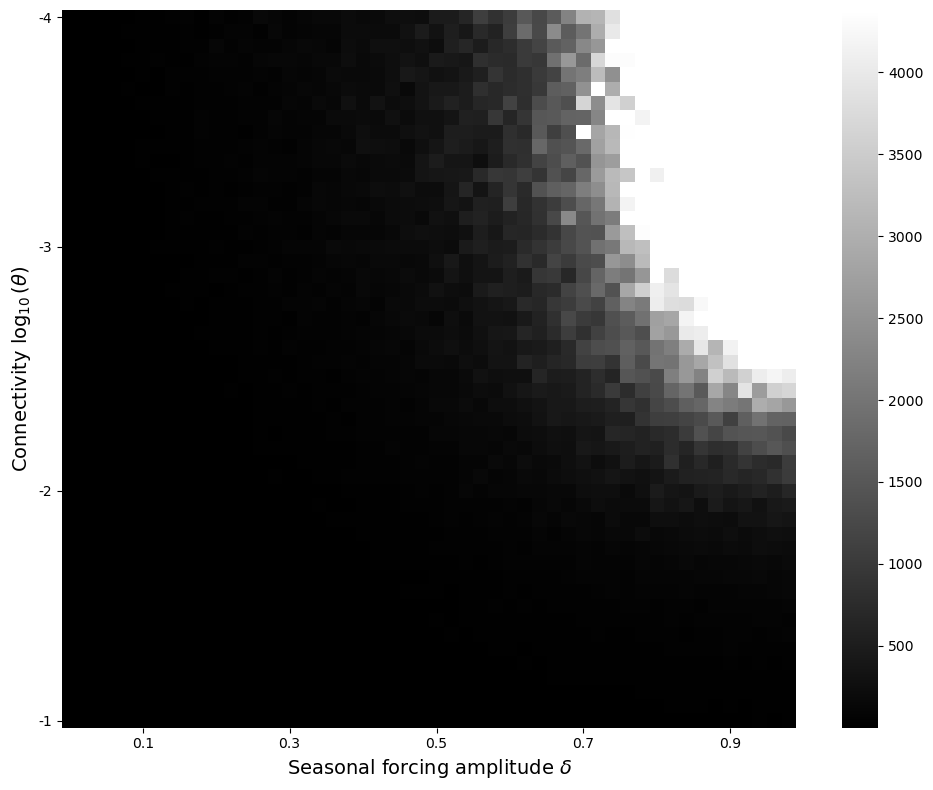

In [2]:
# Cell 1: CRLB Ratio Heatmap (sync / unsync)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed

def median_ratio(pp):
    sync = pp.query("phase2 == 0").crlb.values
    unsync = pp.query("phase2 > 0").crlb.values
    ret =  np.median(sync) / np.median(unsync)
    return ret

    
df = pd.read_csv("outputs/crlb.csv")
df = df.rename(columns={'delta': 'amplitude'})
groups = list(df.groupby(['amplitude', 'theta']))
results = Parallel(n_jobs=-1)(delayed(median_ratio)(group) for name, group in groups)
index = pd.MultiIndex.from_tuples([name for name, group in groups], names=['amplitude', 'theta'])
agg = pd.Series(results, index=index)

heat = agg.unstack(level='amplitude')
heat.index = np.log10(heat.index)
vmax = np.percentile(heat.values.flatten(), 90)

plt.figure(figsize=(10, 8))
ax = sns.heatmap(heat, cmap='grey', xticklabels=False, yticklabels=False, vmin=1, vmax=vmax)
amplitudes = heat.columns.values
thetas = heat.index.values
x_desired = [0.1, 0.3, 0.5, 0.7, 0.9]
x_positions = [np.argmin(np.abs(amplitudes - x)) + 0.5 for x in x_desired]
ax.set_xticks(x_positions)
ax.set_xticklabels(x_desired)
y_desired = [-1, -2, -3, -4]
y_positions = [np.argmin(np.abs(thetas - y)) + 0.5 for y in y_desired]
ax.set_yticks(y_positions)
ax.set_yticklabels(y_desired)
plt.ylabel(r'Connectivity $\log_{10}(\theta)$', fontsize=14)
plt.xlabel(r'Seasonal forcing amplitude $\delta$', fontsize=14)
plt.tight_layout()
plt.savefig("pix/crlb_ratio.png", dpi=150)
plt.savefig("pix/crlb_ratio.pdf")
plt.show()

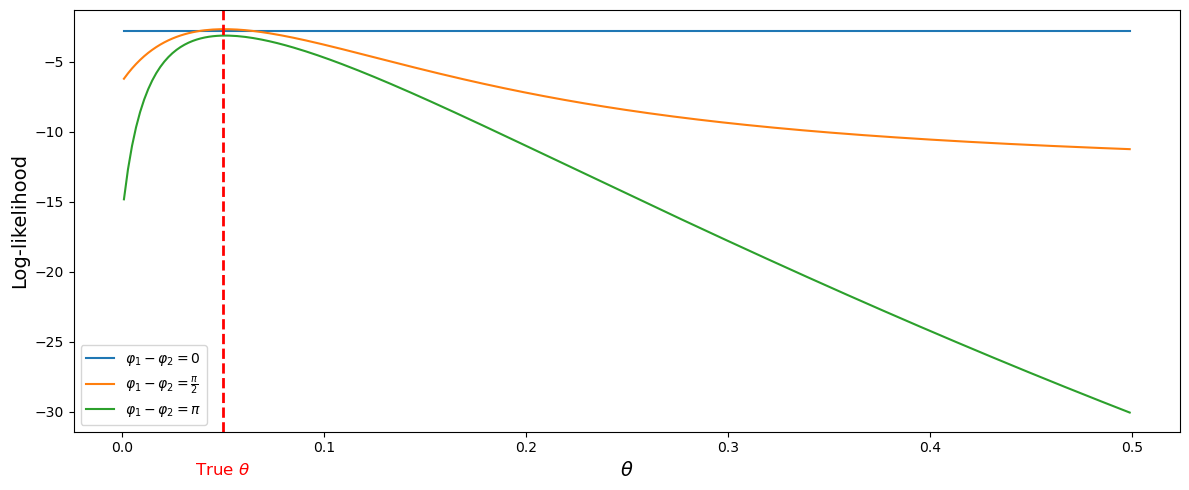

In [3]:
# Cell 2: Profile Likelihood Surface (sync vs unsync)
# For each set of initial conditions, sweep theta over a grid and compute log-likelihood.
# Same data and same ICs across all theta values -> smooth curves.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src import flu
from src.packer import Packer
from src.objective import Objective

N_POP = 1e7
disease = flu.Mortality
regions = ["A", "B"]
n_season = 10
seasons = list(range(n_season))
thetas = np.linspace(0.001, 0.499, 250)
populations = {(s, r): N_POP for s in seasons for r in regions}
packer = Packer(disease=disease, seasons=seasons, regions=regions, populations=populations)
theta = 0.05
true = dict(I_init=np.ones((n_season,2))*np.random.uniform(1e-4, 1e-3), S_init=np.ones((n_season,2))*np.random.uniform(0.8, 0.9), theta=theta)

fig, ax = plt.subplots(1, 1, figsize=(12, 5))

phases = [0, np.pi/4, np.pi/2, np.pi]
labels = [r"$\varphi_1-\varphi_2=0$", r"$\varphi_1-\varphi_2=\frac{\pi}{4}$", r"$\varphi_1-\varphi_2 = \frac{\pi}{2}$", r"$\varphi_1-\varphi_2= \pi$"]
for i, (phase2, label) in enumerate(zip(phases, labels)):
    phase = np.array([0.0, phase2])
    if i in [1]:
        continue
    true['theta'] = theta
    
    obs = packer.sim(true, phase, disease)
    mu = obs['mu']
    scale = np.sqrt(disease.rho * (1 - disease.rho) * mu)
    obs['incidence'] = mu * disease.rho + np.random.randn(len(mu)) * scale

    obj = Objective(obs=obs, phase=phase, disease=disease, populations=populations)

    lls = []
    for th in thetas:
        true['theta'] = th
        x = packer.pack(true)
        lls.append(-obj(x))
    ax.plot(thetas, lls, label=label)

ax.axvline(x=theta, color='red', linestyle='--', linewidth=2)
ax.annotate(r'True $\theta$', xy=(theta, 0), xycoords=('data', 'axes fraction'),
            xytext=(0, -22), textcoords='offset points',
            ha='center', va='top', fontsize=12, color='red')
ax.set_xlabel(r"$\theta$", fontsize=14)
ax.set_ylabel("Log-likelihood", fontsize=14)
ax.legend()

plt.tight_layout()
plt.savefig("pix/likelihood_surface.png", dpi=150, bbox_inches='tight')
plt.savefig("pix/likelihood_surface.pdf", bbox_inches='tight')
plt.show()

In [ ]:
# Cell 3: Raw P&I Death Counts for Representative States
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/pni_mortality/deaths.csv", parse_dates=["date"])
states = ["California", "New York", "Texas", "Florida"]
df = df[df["state"].isin(states)].sort_values("date")

fig, ax = plt.subplots(1, 1, figsize=(12, 8), sharex=True)
for state in states:
    dd = df[df["state"] == state]
    ax.plot(dd["date"], dd["deaths"], linewidth=0.8, label=state)
    ax.set_ylabel("Deaths")
    ax.set_title(state)
    ax.grid(True, alpha=0.3)


ax.set_xlabel("Date")
plt.legend()
plt.tight_layout()
plt.savefig("pix/raw_deaths.png", dpi=150, bbox_inches='tight')
plt.savefig("pix/raw_deaths.pdf", bbox_inches='tight')
plt.show()

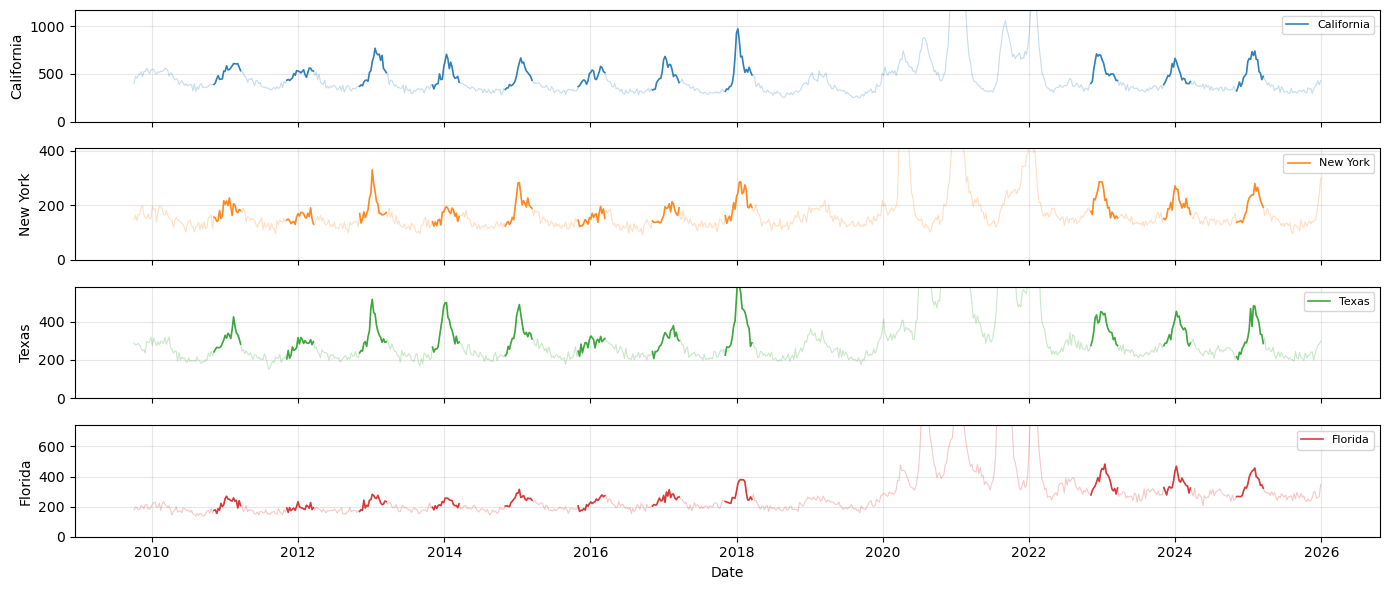

In [12]:
# P&I Deaths with flu seasons highlighted
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.flu import Mortality as flu

df = pd.read_csv("data/pni_mortality/deaths.csv", parse_dates=["date"])
states = ["California", "New York", "Texas", "Florida"]
colors = {"California": "C0", "New York": "C1", "Texas": "C2", "Florida": "C3"}
seasons = list(range(2011, 2019)) + [2023, 2024, 2025]
n_weeks = flu.n_weeks

fig, axes = plt.subplots(4, 1, figsize=(14, 6), sharex=True)

for ax, state in zip(axes, states):
    dd = df[df["state"] == state].sort_values("date")
    c = colors[state]

    # Full time series: light, transparent
    ax.plot(dd["date"], dd["deaths"], color=c, linewidth=0.8, alpha=0.25)

    # Flu seasons: dark, opaque
    for s_idx, season in enumerate(seasons):
        start = pd.Timestamp(year=season - 1, month=11, day=1)
        end = start + pd.Timedelta(weeks=n_weeks)
        mask = (dd["date"] >= start) & (dd["date"] < end)
        ss = dd[mask]
        if not ss.empty:
            ax.plot(ss["date"], ss["deaths"], color=c, linewidth=1.2, alpha=0.9,
                    label=state if s_idx == 0 else None)

    ax.set_ylim(0, dd["deaths"].max() / 3)
    ax.set_ylabel(state, fontsize=10)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.savefig("pix/seasons_highlighted.png", dpi=150, bbox_inches='tight')
plt.savefig("pix/seasons_highlighted.pdf", bbox_inches='tight')
plt.show()

0.0252

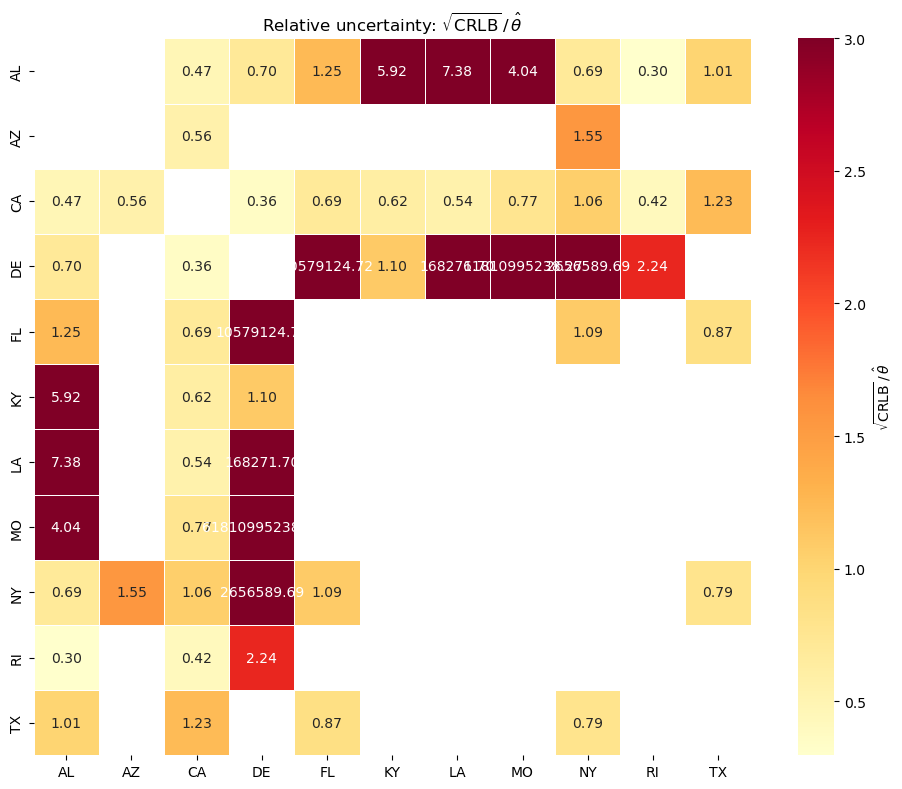

In [16]:
# Cell 5: CRLB/theta ratio heatmap across state pairs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

files = sorted(glob("outputs/states/*.csv"))
if files:
    all_res = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

    # Aggregate CRLB across seasons per pair
    pairs = []
    for (s1, s2), grp in all_res.groupby(['state1', 'state2']):
        theta = grp['theta'].iloc[0]
        crlb_std = np.sqrt(1 / np.sum(1 / grp['crlb']))
        pairs.append({'state1': s1, 'state2': s2, 'ratio': crlb_std / theta})
    pairs = pd.DataFrame(pairs)

    # Build symmetric matrix
    all_states = sorted(set(pairs['state1']) | set(pairs['state2']))
    mat = pd.DataFrame(np.nan, index=all_states, columns=all_states)
    for _, row in pairs.iterrows():
        mat.loc[row['state1'], row['state2']] = row['ratio']
        mat.loc[row['state2'], row['state1']] = row['ratio']

    plt.figure(figsize=(10, 8))
    sns.heatmap(mat.astype(float), cmap='YlOrRd', annot=True, fmt='.2f',
                square=True, linewidths=0.5, vmax=3,
                cbar_kws={'label': r'$\sqrt{\mathrm{CRLB}} \,/\, \hat{\theta}$'})
    plt.title(r'Relative uncertainty: $\sqrt{\mathrm{CRLB}} \,/\, \hat{\theta}$')
    plt.tight_layout()
    plt.savefig("pix/crlb_ratio_states.png", dpi=150, bbox_inches='tight')
    plt.savefig("pix/crlb_ratio_states.pdf", bbox_inches='tight')
    plt.show()
else:
    print("No results files found in outputs/states/")